In [78]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [103]:
class wND(nn.Module):
    """Wrapped normal distribution.
    
    Args:
        n (int): The truncated index for approximating the wrapped normal distribution infinite summation.
    
    Mathematics:
        N_w(x | 0, sigma_t^2) = 1/(sqrt(2*pi)*sigma_t)*(sum_-infty^+infty(exp(-(x-mu-k)^2/(2*sigma_t^2))))
        
        The formula can be approximated by truncate the infinite summation at n.
        f_w,n(x | 0, sigma_t^2) = 1/(sqrt(2*pi)*sigma_t)*(sum_-n^+n(exp(-(x-mu-k)^2/(2*sigma_t^2))))
        
        The logarithmic gradient of f can be formulated
        grad_x log(f_w,n (x | 0, sigma_t^2)) = (sum_-n^+n (k-mu-x) exp(-(x-mu-k)^2/(2*sigma_t^2)))/
            (sigma_t^2 sum_-n^+n exp(-(x-mu-k)^2/(2*sigma_t^2)))
    """
    def __init__(
        self, n: int = 10,
    ) -> None:
        super(wND, self).__init__()
        self.k = torch.arange(-n, n+1, dtype=torch.float32)
    
    def evaluate(
        self, x: torch.Tensor, mu: float, sigma: float,
    ) -> torch.Tensor:
        """The wrapped normal distribution function.
        
        Args:
            x (torch.Tensor): The input tensor.
            mu (float): The mean of the normal distribution.
            sigma (float): The standard deviation of the normal distribution.
        
        Returns:
            out (Tensor): The wrapped normal distribution function.
        """
        x_mu_k = x.unsqueeze(dim=-1) - mu - self.k
        return self.normal_function(x_mu_k, sigma, normalize=True).sum(dim=-1)
    
    def log_grad(
        self, x: torch.Tensor, mu: float, sigma: float,
    ) -> torch.Tensor:
        """Calculate the log gradient of wrapped normal distribution function.
        
        Args:
            x (torch.Tensor): The input tensor.
            mu (float): The mean of the normal distribution.
            sigma (float): The standard deviation of the normal distribution.
        
        Returns:
            out (Tensor): The log gradient of wrapped normal distribution function.
        """
        x_mu_k = x.unsqueeze(dim=-1) - mu - self.k
        enumerator = -x_mu_k * self.normal_function(x_mu_k, sigma, normalize=False)
        enumerator = enumerator.sum(dim=-1)
        denominator = sigma**2 * self.normal_function(x_mu_k, sigma, normalize=False).sum(dim=-1)
        return enumerator / denominator
    
    @staticmethod
    def normal_function(
        x: torch.Tensor, sigma: float, normalize: bool = False,
    ) -> torch.Tensor:
        """The normal distribution function."""
        out = torch.exp(-(x)**2/(2*sigma**2))
        out = out / (torch.sqrt(torch.tensor(2*torch.pi))*sigma) if normalize else out
        return out

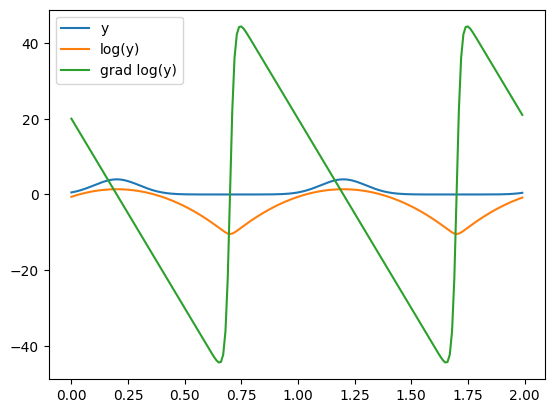

In [108]:
wnd = wND(n=10)
y = wnd.evaluate(torch.arange(0, 2, 0.01), mu=0.2, sigma=0.1)
y_log_grad = wnd.log_grad(torch.arange(0, 2, 0.01), mu=0.2, sigma=0.1)

plt.plot(torch.arange(0, 2, 0.01), y, label='y')
plt.plot(torch.arange(0, 2, 0.01), torch.log(y), label="log(y)")
plt.plot(torch.arange(0, 2, 0.01), y_log_grad, label='grad log(y)')
plt.legend()